Importing the Dependencies

In [97]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Lasso
from sklearn import metrics
from sklearn.preprocessing import LabelEncoder

Data Collection and Processing

In [98]:
# loading the data from csv file to pandas dataframe
car_dataset = pd.read_csv('/content/car_data.csv')

In [99]:
# inspecting the first 5 rows of the dataframe
car_dataset.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner
3,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner
4,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner


In [100]:
# checking the number of rows and columns
car_dataset.shape

(4340, 8)

In [101]:
# getting some information about the dataset
car_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4340 entries, 0 to 4339
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   name           4340 non-null   object
 1   year           4340 non-null   int64 
 2   selling_price  4340 non-null   int64 
 3   km_driven      4340 non-null   int64 
 4   fuel           4340 non-null   object
 5   seller_type    4340 non-null   object
 6   transmission   4340 non-null   object
 7   owner          4340 non-null   object
dtypes: int64(3), object(5)
memory usage: 271.4+ KB


In [102]:
# checking the number of missing values
car_dataset.isnull().sum()

,0
name,0
year,0
selling_price,0
km_driven,0
fuel,0
seller_type,0
transmission,0
owner,0


In [103]:
# checking the distribution of categorical data
print(car_dataset.fuel.value_counts())
print(car_dataset.seller_type.value_counts())
print(car_dataset.transmission.value_counts())

fuel
Diesel      2153
Petrol      2123
CNG           40
LPG           23
Electric       1
Name: count, dtype: int64
seller_type
Individual          3244
Dealer               994
Trustmark Dealer     102
Name: count, dtype: int64
transmission
Manual       3892
Automatic     448
Name: count, dtype: int64


Encoding the Categorical Data

In [104]:
le = LabelEncoder()

car_dataset['fuel'] = le.fit_transform(car_dataset['fuel'])
car_dataset['seller_type'] = le.fit_transform(car_dataset['seller_type'])
car_dataset['transmission'] = le.fit_transform(car_dataset['transmission'])
car_dataset['owner'] = le.fit_transform(car_dataset['owner'])

In [105]:
car_dataset.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,Maruti 800 AC,2007,60000,70000,4,1,1,0
1,Maruti Wagon R LXI Minor,2007,135000,50000,4,1,1,0
2,Hyundai Verna 1.6 SX,2012,600000,100000,1,1,1,0
3,Datsun RediGO T Option,2017,250000,46000,4,1,1,0
4,Honda Amaze VX i-DTEC,2014,450000,141000,1,1,1,2


Splitting the data and Target

In [106]:
X = car_dataset.drop(['name','selling_price'], axis=1)
Y = car_dataset['selling_price']

In [107]:
print(X)

      year  km_driven  fuel  seller_type  transmission  owner
0     2007      70000     4            1             1      0
1     2007      50000     4            1             1      0
2     2012     100000     1            1             1      0
3     2017      46000     4            1             1      0
4     2014     141000     1            1             1      2
...    ...        ...   ...          ...           ...    ...
4335  2014      80000     1            1             1      2
4336  2014      80000     1            1             1      2
4337  2009      83000     4            1             1      2
4338  2016      90000     1            1             1      0
4339  2016      40000     4            1             1      0

[4340 rows x 6 columns]


In [108]:
print(Y)

0        60000
1       135000
2       600000
3       250000
4       450000
         ...  
4335    409999
4336    409999
4337    110000
4338    865000
4339    225000
Name: selling_price, Length: 4340, dtype: int64


In [109]:
print(X.dtypes)

year            int64
km_driven       int64
fuel            int64
seller_type     int64
transmission    int64
owner           int64
dtype: object


Splitting Training and Test data

In [110]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.1, random_state=2)

Model Training

1. Linear Regression

In [111]:
# loading the linear regression model
lin_reg_model = LinearRegression()

In [112]:
lin_reg_model.fit(X_train,Y_train)

LinearRegression()

Model Evaluation

In [113]:
# prediction on Training data
training_data_prediction = lin_reg_model.predict(X_train)
print(training_data_prediction)

[750986.41214396 409632.13010781 549023.56110936 ... 569243.95788011
 439905.59174673 467863.86638698]


In [114]:
# R squared Error
error_score = metrics.r2_score(Y_train, training_data_prediction)
print("R squared Error : ", error_score)

R squared Error :  0.4414460114370832


Visualize the actual prices and Predicted prices

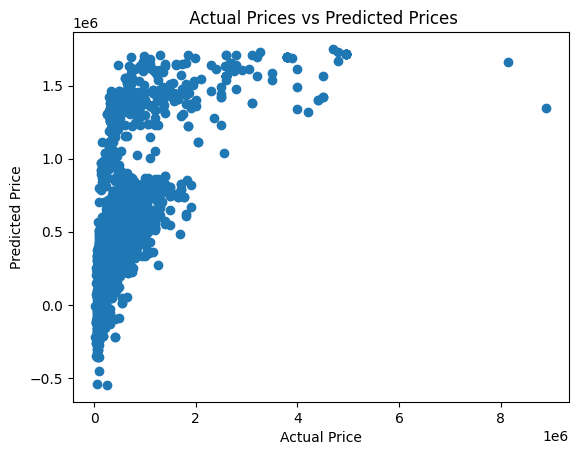

In [115]:
plt.scatter(Y_train, training_data_prediction)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title(" Actual Prices vs Predicted Prices")
plt.show()

In [116]:
# prediction on Training data
test_data_prediction = lin_reg_model.predict(X_test)
print(test_data_prediction)


[ 452656.12781975 1386420.66685152  228381.91387899 1407775.47890328
  743328.71645527  461202.63041864  402466.67245415  -55301.27496393
  286754.85535432  499903.43406145  258401.51301086   66871.63351579
 1254987.75900003  625440.00559011  -99693.89557803 1592700.54383063
  537437.20462678  594846.11110014 1422012.96025503  419685.194976
  444055.36850363  384029.97688778   91624.2275849  1220289.7528729
 1604118.68231279  461202.63041864 1485378.05280226  679388.75277141
  303997.46460356  813997.7308379   330307.16147897    6278.36390229
  750097.60523377  568712.47208579   23168.30188476 1422012.96025503
  504645.7825612   289815.19924986  509488.95463979  534665.38169305
  832706.74995229  705140.69736919 1391037.90163875  706665.74586895
 1569078.25720917  286410.32818811  580251.89543261  575344.5507625
  604143.95387983  280774.70923175  517078.2452776   313569.58421443
  432486.27158602  734424.89274049  404023.77526045  165086.97885932
  564764.67865354  427700.21178058  50

In [117]:
# R squared Error
error_score = metrics.r2_score(Y_test, test_data_prediction)
print("R squared Error : ", error_score)

R squared Error :  0.5148590930573664


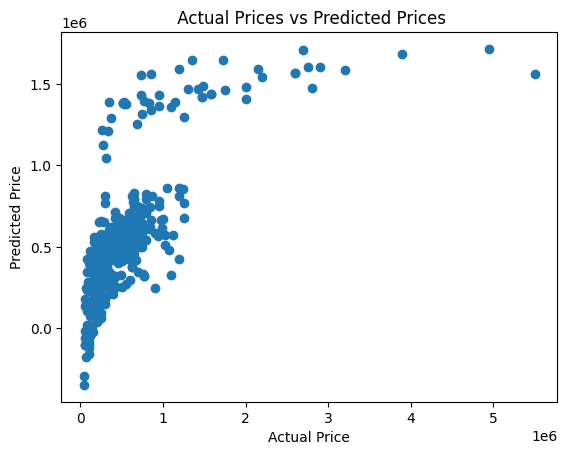

In [118]:
plt.scatter(Y_test, test_data_prediction)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title(" Actual Prices vs Predicted Prices")
plt.show()

2. Lasso Regression

In [119]:
# loading the linear regression model
lass_reg_model = Lasso()

In [120]:
lass_reg_model.fit(X_train,Y_train)

Lasso()

Model Evaluation

In [121]:
# prediction on Training data
training_data_prediction = lass_reg_model.predict(X_train)
print(training_data_prediction)

[750988.0121807  409632.1629838  549026.47052096 ... 569244.97661793
 439906.08581473 467863.93055154]


In [122]:
# R squared Error
error_score = metrics.r2_score(Y_train, training_data_prediction)
print("R squared Error : ", error_score)

R squared Error :  0.4414460113936829


Visualize the actual prices and Predicted prices

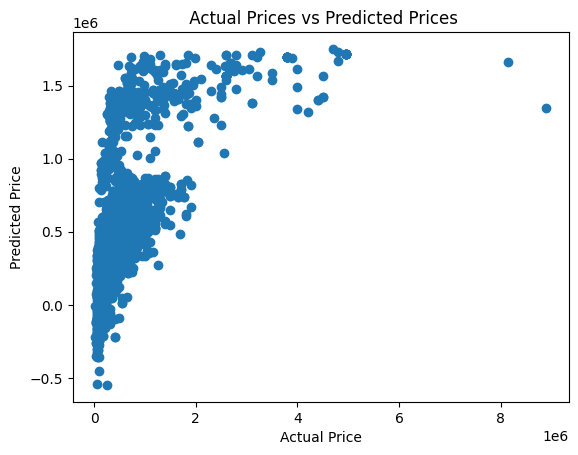

In [123]:
plt.scatter(Y_train, training_data_prediction)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title(" Actual Prices vs Predicted Prices")
plt.show()

In [124]:
# prediction on test data
test_data_prediction = lass_reg_model.predict(X_test)
print(test_data_prediction)

[ 452654.89993149 1386409.56350251  228382.72875501 1407765.79673959
  743330.25011824  461205.17622247  402468.00225532  -55299.6602374
  286752.98467799  499902.41689946  258403.29498792   66875.06983733
 1254979.61364703  625437.41420966  -99692.74876264 1592688.16852497
  537434.24806219  594846.95415886 1422001.9666114   419687.57971777
  444061.66409057  384030.18544288   91626.32062531 1220279.43962996
 1604110.10558937  461205.17622247 1485365.34365135  679386.43020254
  304000.40443794  813998.59200351  330308.97032261    6277.77420573
  750095.49795218  568709.58780837   23165.53810649 1422001.9666114
  504647.60042092  289810.69278134  509488.02056114  534668.16665383
  832708.85951337  705145.99723665 1391029.43343303  706663.46093185
 1569073.27517827  286413.31437846  580253.00958273  575345.42358375
  604141.17791395  280776.48633647  517081.07659434  313572.60701604
  432488.56848823  734422.8484083   404025.31735198  165089.31105666
  564763.82609414  427702.46719918  

In [125]:
# R squared Error
error_score = metrics.r2_score(Y_test, test_data_prediction)
print("R squared Error : ", error_score)

R squared Error :  0.5148588143772478


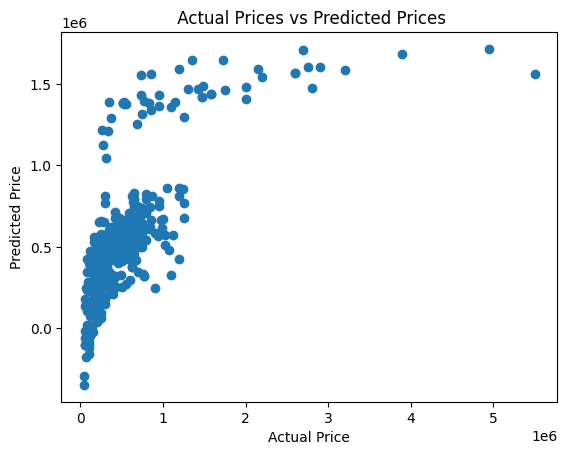

In [126]:
plt.scatter(Y_test, test_data_prediction)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title(" Actual Prices vs Predicted Prices")
plt.show()